In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import pandas as pd

import json

In [2]:
# Hyperparameters
gamma = 0.99
gamma_list = np.cumprod(np.repeat(gamma, 20))

In [3]:
def summarize_hist(dir):
    with open(dir, 'r') as f:
        sim = json.load(f)
        
#     sim = np.stack(sim)
#     sim_mean = np.mean(sim, axis=0)
    sim_default = []
    sim_lap_1 = []
    sim_lap_2 = []
    sim_iso = []
    sim_ep = []
    for i in range(len(sim)):    
        sim_default_mean, sim_default_std = np.stack(sim[i][0]), np.stack(sim[i][5])
        sim_lap_1_mean, sim_lap_1_std = np.stack(sim[i][1]), np.stack(sim[i][6])
        sim_lap_2_mean, sim_lap_2_std = np.stack(sim[i][2]), np.stack(sim[i][7])
        sim_iso_mean, sim_iso_std = np.stack(sim[i][3]), np.stack(sim[i][8])
        sim_ep_mean, sim_ep_std = np.stack(sim[i][4]), np.stack(sim[i][9])
        
        sim_default.append(sim_default_mean)
        sim_lap_1.append(sim_lap_1_mean)
        sim_lap_2.append(sim_lap_2_mean)
        sim_iso.append(sim_iso_mean)
        sim_ep.append(sim_ep_mean)
    sim_default = np.mean(np.stack(sim_default), axis=0)
    sim_lap_1 = np.mean(np.stack(sim_lap_1), axis=0)
    sim_lap_2 = np.mean(np.stack(sim_lap_2), axis=0)
    sim_iso = np.mean(np.stack(sim_iso), axis=0)
    ep_data = np.stack(sim_ep)
    sim_ep = np.mean(np.stack(sim_ep), axis=0)
    
    return sim_default, sim_lap_1, sim_lap_2, sim_iso, sim_ep, ep_data

In [11]:
data = summarize_hist("history/quad_20_0.5_30_2024-11-29-13-43-01.json")

In [12]:
with open("history/quad_10_1_30_2024-11-16-07-56-54.json", 'r') as f:
    sim_0 = json.load(f)

In [13]:
np.median(data[5][:, 0, 0, 25]), np.mean(data[5][:, 0, 0, 25])

(0.2018272053100843, 0.22415125566208033)

In [14]:
for i in range(30):
    print(data[5][i, 0, 0, 20:])

[0.37905663 0.41578019 0.43587788 0.41306762 0.44893811 0.42908352
 0.45009443 0.39907911 0.37637284 0.40631882]
[0.31093127 0.36579352 0.33267646 0.32532195 0.31473868 0.29982448
 0.27495911 0.20412517 0.2973353  0.2700431 ]
[0.37975427 0.38402523 0.33210874 0.36214215 0.35195605 0.31118578
 0.32587159 0.34257283 0.44707616 0.38834509]
[0.20755625 0.32083598 0.35348341 0.33608384 0.28975237 0.36027407
 0.30734344 0.36934501 0.25193727 0.28435344]
[0.36443608 0.41070054 0.42937774 0.39756719 0.42687079 0.43142221
 0.38712473 0.18961943 0.07890409 0.04551528]
[0.0050273  0.04198891 0.01909046 0.0508963  0.05502399 0.01556994
 0.0287492  0.02350963 0.03148456 0.03303765]
[0.01355761 0.01266099 0.02420768 0.01627227 0.03588256 0.04063523
 0.06191089 0.07060589 0.13561406 0.15661378]
[0.53300027 0.54055537 0.45542382 0.50879615 0.48644234 0.51357491
 0.56024749 0.47253541 0.44389717 0.49499389]
[0.06267292 0.00215112 0.03681656 0.01801736 0.0248032  0.08356964
 0.00206645 0.07734944 0.0761

In [15]:
# Setup parameters
start_idx = 5
limit = data[0].shape[2]-2
t_list = range(start_idx, limit)

SMALL_SIZE = 18
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=15)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

Text(0.1, 0.5, '$\\lvert \\mu_1^{(i)}-\\hat{\\mu}_1^{(i)} \\rvert$')

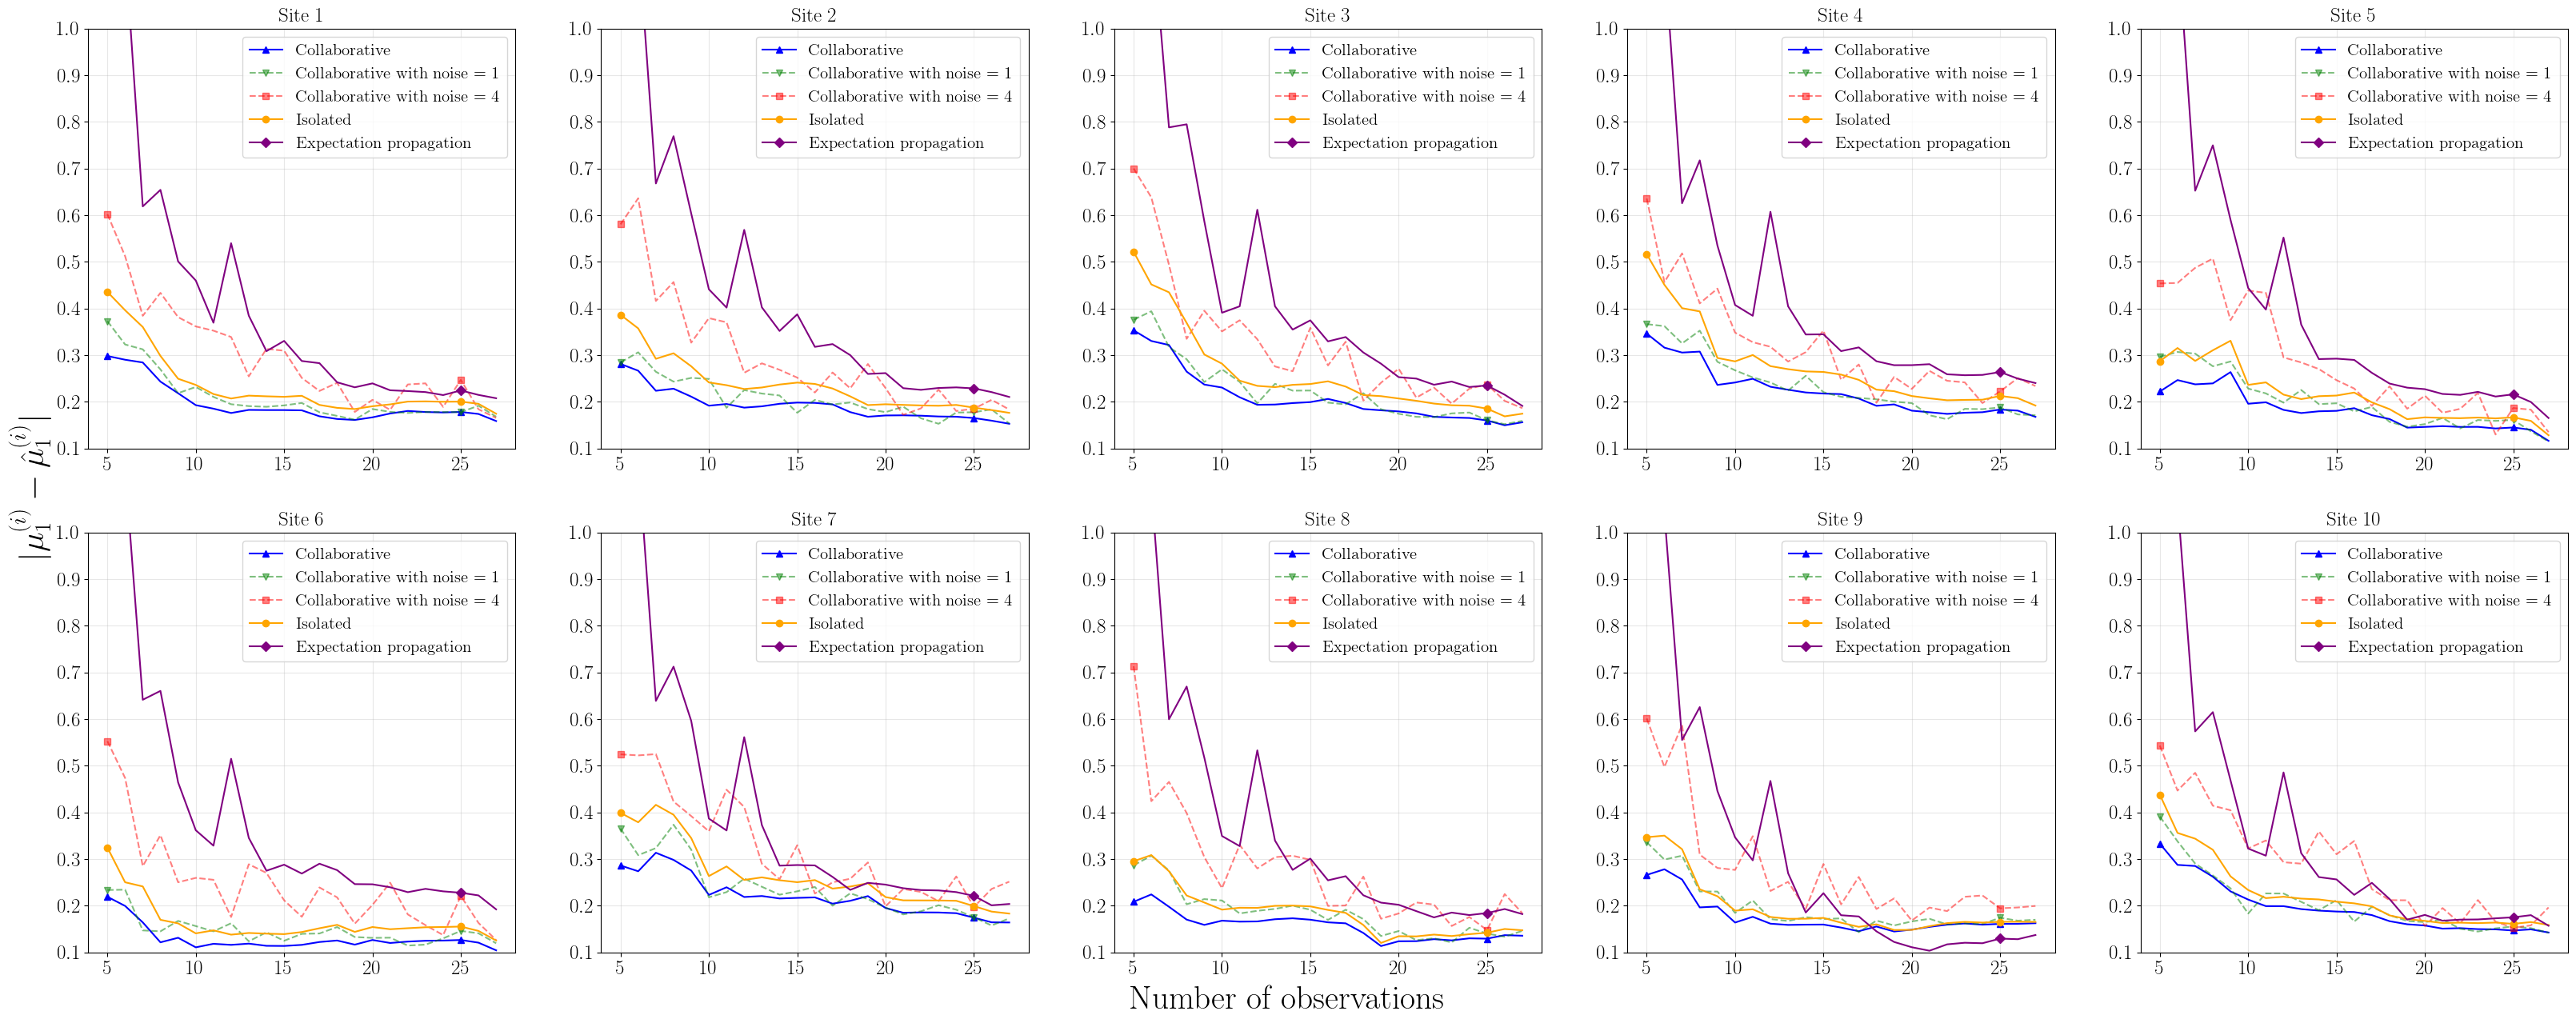

In [16]:
fig, ax = plt.subplots(2, 5, figsize=(40, 15))

# fig.supxlabel("Communication rounds")
# Plotting 10 sites
for i in range(10):        
    linear_line = data[0][i, 0, start_idx:limit]
    linear_line_lap_1 = data[1][i, 0, start_idx:limit]
    linear_line_lap_2 = data[2][i, 0, start_idx:limit]
    linear_line_iso = data[3][i, 0, start_idx:limit]
    linear_line_ep = data[4][i, 0, start_idx:limit]

    ax[i // 5, i % 5].plot(t_list, linear_line, label="Collaborative", color='blue', marker='^', markevery=20)
    ax[i // 5, i % 5].plot(t_list, linear_line_lap_1, label="Collaborative with noise = 1", color='green', marker='v', linestyle='--', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, linear_line_lap_2, label="Collaborative with noise = 4", color='red', marker='s', linestyle='--', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, linear_line_iso, label="Isolated", color='orange', marker='o', markevery=20)
    ax[i // 5, i % 5].plot(t_list, linear_line_ep, label="Expectation propagation", color='purple', marker='D', markevery=20)
    #     ax[i//5, i%5].fill_between(t_list, linear_line - linear_line_std, linear_line + linear_line_std, color='blue', alpha=0.1)
    ax[i // 5, i % 5].grid(visible=True, alpha=0.3)
    ax[i // 5, i % 5].set_ylim([0.1, 1])
    ax[i // 5, i % 5].set_title(f'Site {i+1}')
    ax[i // 5, i % 5].legend()

ylabel = r'$\lvert \mu_1^{(i)}-\hat{\mu}_1^{(i)} \rvert$'
fig.text(0.5, 0.07, 'Number of observations', ha='center', va='center', fontsize=30)
fig.text(0.1, 0.5, ylabel , va='center', rotation='vertical', fontsize=30)

Text(0.1, 0.5, '$\\lvert \\mu_1^{(i)}-\\hat{\\mu}_1^{(i)} \\rvert$')

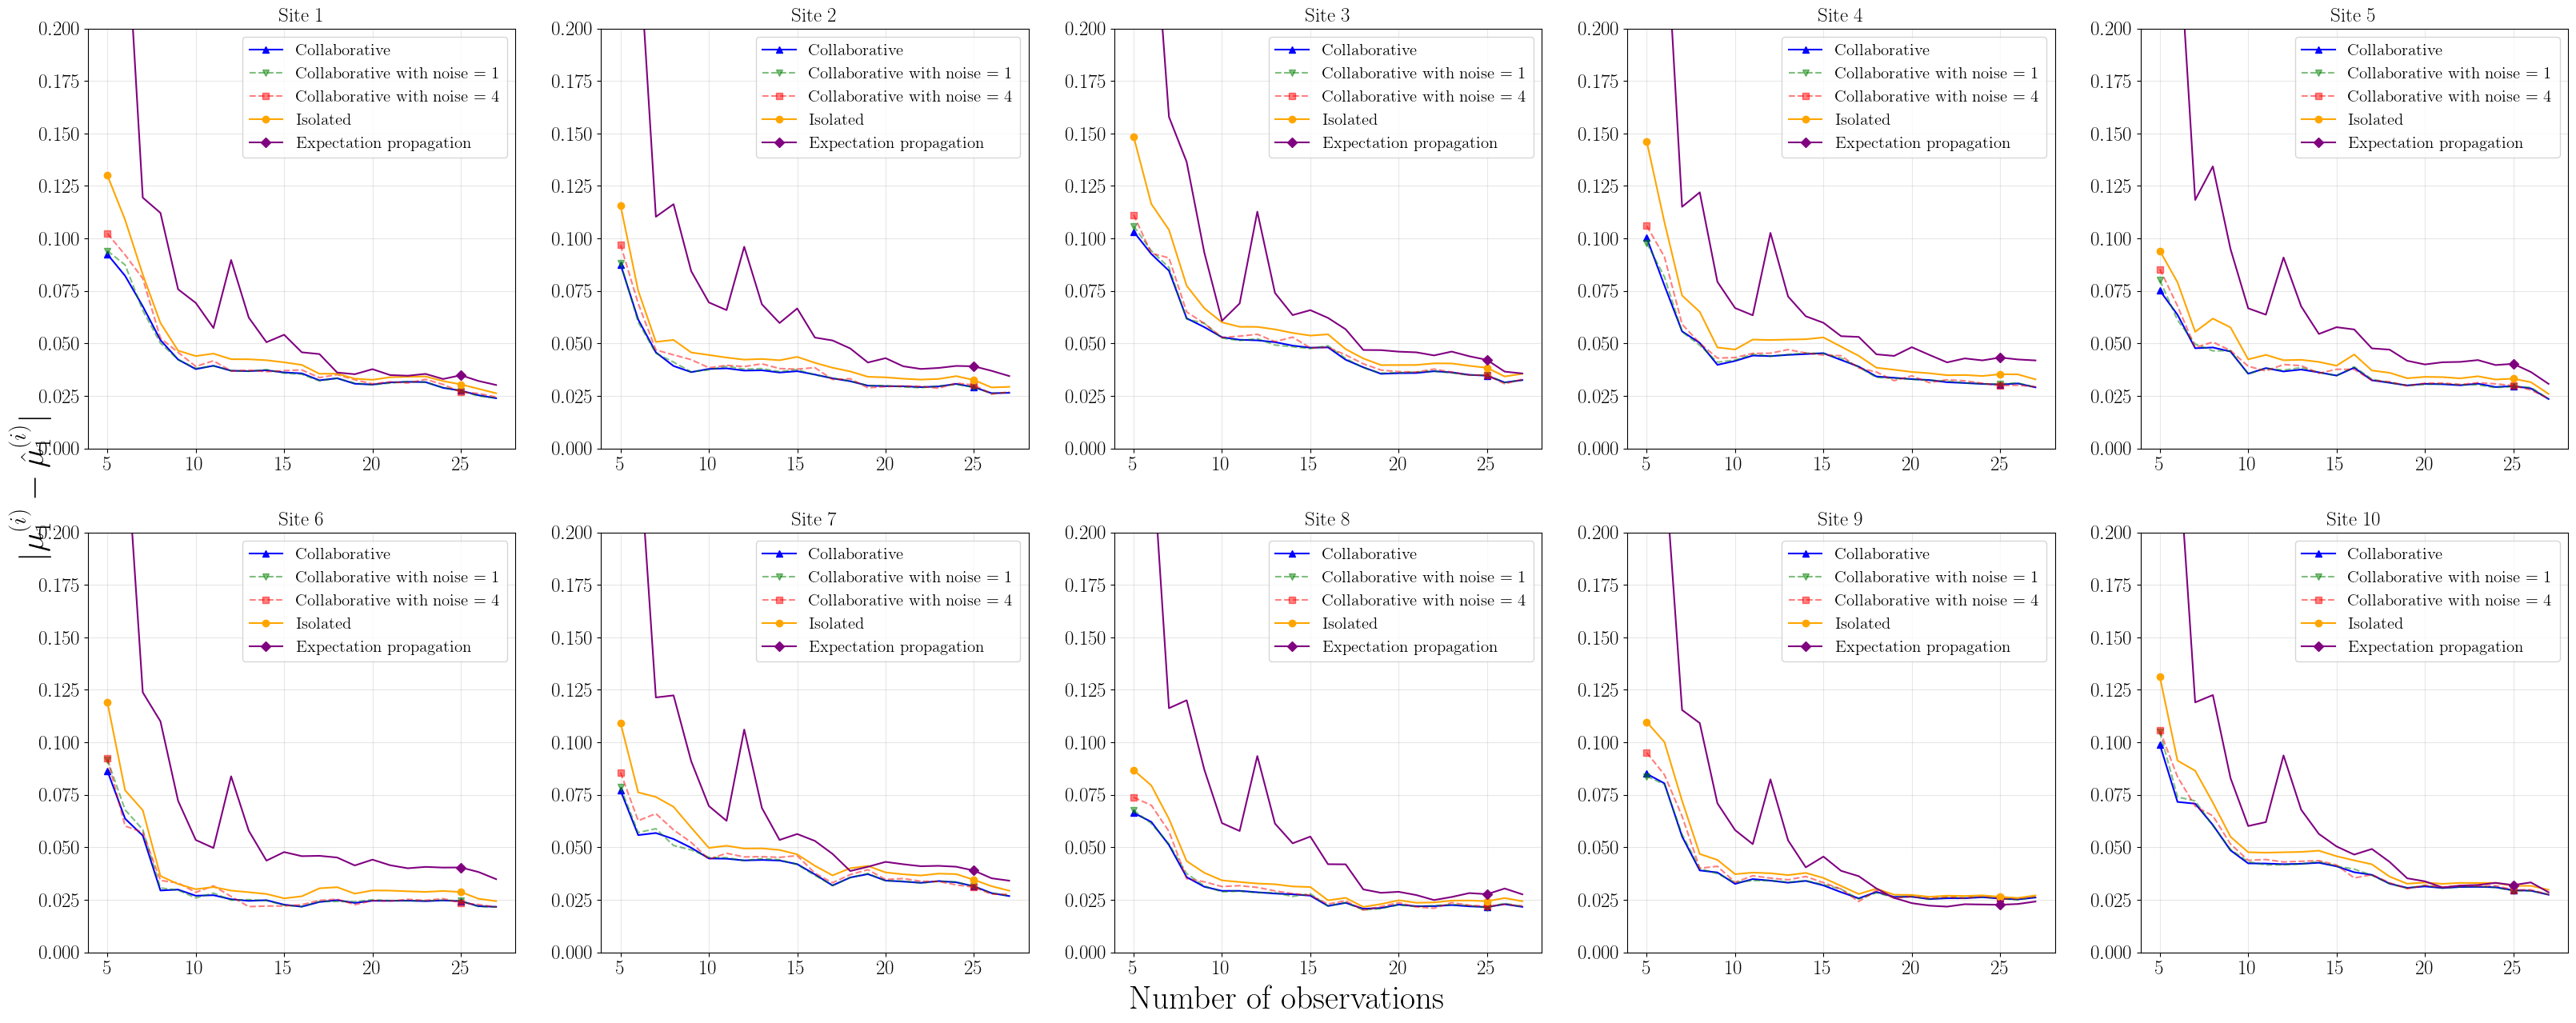

In [17]:
fig, ax = plt.subplots(2, 5, figsize=(40, 15))

# fig.supxlabel("Communication rounds")
# Plotting 10 sites
for i in range(10):        
    linear_line = data[0][i, 1, start_idx:limit]
    linear_line_lap_1 = data[1][i, 1, start_idx:limit]
    linear_line_lap_2 = data[2][i, 1, start_idx:limit]
    linear_line_iso = data[3][i, 1, start_idx:limit]
    linear_line_ep = data[4][i, 1, start_idx:limit]

    ax[i // 5, i % 5].plot(t_list, linear_line, label="Collaborative", color='blue', marker='^', markevery=20)
    ax[i // 5, i % 5].plot(t_list, linear_line_lap_1, label="Collaborative with noise = 1", color='green', marker='v', linestyle='--', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, linear_line_lap_2, label="Collaborative with noise = 4", color='red', marker='s', linestyle='--', markevery=20, alpha=0.5)
    ax[i // 5, i % 5].plot(t_list, linear_line_iso, label="Isolated", color='orange', marker='o', markevery=20)
    ax[i // 5, i % 5].plot(t_list, linear_line_ep, label="Expectation propagation", color='purple', marker='D', markevery=20)
    #     ax[i//5, i%5].fill_between(t_list, linear_line - linear_line_std, linear_line + linear_line_std, color='blue', alpha=0.1)
    ax[i // 5, i % 5].grid(visible=True, alpha=0.3)
    ax[i // 5, i % 5].set_ylim([0., 0.2])
    ax[i // 5, i % 5].set_title(f'Site {i+1}')
    ax[i // 5, i % 5].legend()

ylabel = r'$\lvert \mu_1^{(i)}-\hat{\mu}_1^{(i)} \rvert$'
fig.text(0.5, 0.07, 'Number of observations', ha='center', va='center', fontsize=30)
fig.text(0.1, 0.5, ylabel , va='center', rotation='vertical', fontsize=30)